# Comprehensive OCR Architecture Experiments

This notebook benchmarks **four custom neural network architectures** for OCR from scratch to find the lowest possible Character Error Rate (CER).

The contenders are
1. Standard CRNN with Bidirectional LSTMs
2. Fully Convolutional Network using TCNs
3. Sequence to Sequence with Self Attention
4. Pure Vision Transformer Encoder

All models share the same CNN front-end, CTC loss layer, and evaluation callback, making the comparison fair and direct.

In [ ]:
%pip install jiwer

In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from jiwer import cer

from google.colab import drive
import os
import zipfile

In [ ]:
drive.mount('/content/drive')

ZIP_PATH     = '/content/drive/MyDrive/cig_ps.zip'
EXTRACT_PATH = '/content/cig_ps_local'

if not os.path.exists(EXTRACT_PATH):
    print(f"Extracting {ZIP_PATH} to local storage...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction complete.")
else:
    print("Data already present locally — skipping extraction.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already present locally — skipping extraction.


In [ ]:
DATA_DIR          = Path(EXTRACT_PATH)
TRAIN_IMAGES_DIR  = DATA_DIR / "cig_ps/train_images"
TRAIN_CSV_PATH    = DATA_DIR / "cig_ps/train-labels.csv"
TEST_IMAGES_DIR   = DATA_DIR / "cig_ps/test_images"

In [ ]:
PAD_TOKEN = 99
BATCH_SIZE = 64
IMG_WIDTH  = 200
IMG_HEIGHT = 100

# Data Preparation

In [ ]:
df = pd.read_csv(TRAIN_CSV_PATH)
df['image_path'] = df['image'].apply(lambda x: str(TRAIN_IMAGES_DIR / x))
df['label'] = df['text']

In [ ]:
print(f"Total samples : {len(df)}")
df.head()

Total samples : 20000


,Unnamed: 0,image,text,image_path,label
0,0,train-0.png,BU522X,/content/cig_ps_local/cig_ps/train_images/trai...,BU522X
1,1,train-1.png,XQ8NE2,/content/cig_ps_local/cig_ps/train_images/trai...,XQ8NE2
2,2,train-2.png,DTZD3E,/content/cig_ps_local/cig_ps/train_images/trai...,DTZD3E
3,3,train-3.png,SM424H,/content/cig_ps_local/cig_ps/train_images/trai...,SM424H
4,4,train-4.png,6YVTQR,/content/cig_ps_local/cig_ps/train_images/trai...,6YVTQR


In [ ]:
characters = sorted(set(char for label in df['text'].astype(str) for char in label))

In [ ]:
print(f"Vocabulary size : {len(characters)}")
print(f"Characters      : {''.join(characters)}")

Vocabulary size : 38
Characters      : +-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar


In [ ]:
char_to_num = layers.StringLookup(
    vocabulary = list(characters),
    mask_token = None
)

num_to_char = layers.StringLookup(
    vocabulary = char_to_num.get_vocabulary(),
    mask_token = None,
    invert = True
)

In [ ]:
def encode_single_sample(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels = 1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.transpose(img, perm = [1, 0, 2])
    label = char_to_num(tf.strings.unicode_split(label, input_encoding = "UTF-8"))
    label = tf.cast(label, tf.float32)
    return {"image": img, "label": label}

In [ ]:
SPLIT_IDX = 17600

train_df = df.iloc[:SPLIT_IDX]
val_df = df.iloc[SPLIT_IDX:]

train_images = train_df['image_path'].values
train_labels = train_df['text'].astype(str).values

val_images = val_df['image_path'].values
val_labels = val_df['text'].astype(str).values

print(f"Training samples : {len(train_images)}")
print(f"Validation samples : {len(val_images)}")

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_dataset = (
    train_dataset
    .map(encode_single_sample, num_parallel_calls = tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padding_values = {"image": 0.0, "label": tf.cast(PAD_TOKEN, tf.float32)}
    )
    .prefetch(buffer_size = tf.data.AUTOTUNE)
)

validation_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
validation_dataset = (
    validation_dataset
    .map(encode_single_sample, num_parallel_calls = tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padding_values = {"image": 0.0, "label": tf.cast(PAD_TOKEN, tf.float32)}
    )
    .prefetch(buffer_size = tf.data.AUTOTUNE)
)

Training samples   : 17600
Validation samples : 2400


# Model Custom Layers

In [ ]:
class CTCLayer(layers.Layer):
    def __init__(self, name = None, **kwargs):
        super().__init__(name = name, **kwargs)
        self.loss_fn = keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = tf.cast(tf.shape(y_true)[0], dtype = "int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype = "int64")
        label_length = tf.reduce_sum(tf.cast(tf.not_equal(y_true, PAD_TOKEN), tf.int64), axis = -1)
        label_length = tf.reshape(label_length, (batch_len, 1))
        input_length = input_length * tf.ones(shape = (batch_len, 1), dtype = "int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

In [ ]:
class CERMetricCallback(keras.callbacks.Callback):
    def __init__(self, dataset, num_to_char, prediction_model):
        super().__init__()
        self.dataset = dataset
        self.num_to_char = num_to_char
        self.prediction_model = prediction_model

    def on_epoch_end(self, epoch, logs = None):
        if logs is None:
            logs = {}
        true_texts = []
        pred_texts = []

        for batch in self.dataset.take(5):
            images = batch["image"]
            labels = batch["label"]
            preds = self.prediction_model.predict(images, verbose = 0)
            input_len = np.ones(preds.shape[0]) * preds.shape[1]
            decoded, _ = keras.backend.ctc_decode(preds, input_length = input_len, greedy = True)
            decoded_seq = decoded[0]
            for i in range(len(images)):
                true_indices = labels[i][labels[i] != PAD_TOKEN]
                true_text = (tf.strings.reduce_join(self.num_to_char(true_indices)).numpy().decode("utf-8"))
                true_texts.append(true_text)
                pred_indices = decoded_seq[i][decoded_seq[i] != -1]
                pred_text = (tf.strings.reduce_join(self.num_to_char(pred_indices)).numpy().decode("utf-8"))
                pred_texts.append(pred_text)

        epoch_cer = cer(true_texts, pred_texts)
        logs["val_cer"] = epoch_cer
        print(f"\nEpoch {epoch + 1} Validation CER: {epoch_cer:.4f}")

In [ ]:
vocab_size = char_to_num.vocabulary_size()
EPOCHS = 50

In [ ]:
def _cnn_backbone(input_img):
    x = layers.Conv2D(32, 3, activation = "relu", padding = "same")(input_img)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation = "relu", padding = "same")(x)
    x = layers.MaxPooling2D(2)(x)
    new_shape = (IMG_WIDTH // 4, (IMG_HEIGHT // 4) * 64)
    x = layers.Reshape(target_shape = new_shape)(x)
    x = layers.Dense(64, activation = "relu")(x)
    x = layers.Dropout(0.2)(x)
    return x

In [ ]:
def build_baseline_crnn(vocab_size):
    input_img = layers.Input(shape = (IMG_WIDTH, IMG_HEIGHT, 1), name = "image", dtype = "float32")
    labels = layers.Input(shape = (None,), name = "label", dtype = "float32")
    x = _cnn_backbone(input_img)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences = True, dropout = 0.25))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences = True, dropout = 0.25))(x)
    x = layers.Dense(vocab_size + 1, activation = "softmax", name = "dense_out")(x)
    output = CTCLayer(name = "ctc_loss")(labels, x)
    model = keras.models.Model(inputs = [input_img, labels], outputs = output, name = "Baseline_CRNN")
    model.compile(optimizer = keras.optimizers.Adam(), jit_compile = False)
    return model

In [ ]:
def build_tcn_model(vocab_size):
    input_img = layers.Input(shape = (IMG_WIDTH, IMG_HEIGHT, 1), name = "image", dtype = "float32")
    labels = layers.Input(shape = (None,), name = "label", dtype = "float32")
    x = _cnn_backbone(input_img)
    x = layers.Conv1D(filters = 128, kernel_size = 5, activation = "relu", padding = "same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters = 128, kernel_size = 5, activation = "relu", padding = "same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(vocab_size + 1, activation = "softmax", name = "dense_out")(x)
    output = CTCLayer(name = "ctc_loss")(labels, x)
    model = keras.models.Model(inputs = [input_img, labels], outputs = output, name = "TCN_Model")
    model.compile(optimizer = keras.optimizers.Adam(), jit_compile = False)
    return model

In [ ]:
def build_attention_model(vocab_size):
    input_img = layers.Input(shape = (IMG_WIDTH, IMG_HEIGHT, 1), name = "image", dtype = "float32")
    labels = layers.Input(shape = (None,), name = "label", dtype = "float32")
    x = _cnn_backbone(input_img)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences = True, dropout = 0.25))(x)
    attention = layers.MultiHeadAttention(num_heads = 4, key_dim = 128, dropout = 0.2)(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)
    x = layers.Dense(vocab_size + 1, activation = "softmax", name = "dense_out")(x)
    output = CTCLayer(name = "ctc_loss")(labels, x)
    model = keras.models.Model(inputs = [input_img, labels], outputs = output, name = "Attention_Model")
    model.compile(optimizer = keras.optimizers.Adam(), jit_compile = False)
    return model

In [ ]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.max_length = max_length
        self.embed_dim = embed_dim
        self.pos_emb = layers.Embedding(input_dim = max_length, output_dim = embed_dim)

    def call(self, inputs):
        positions = tf.range(start = 0, limit = tf.shape(inputs)[1], delta = 1)
        return inputs + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"max_length": self.max_length, "embed_dim": self.embed_dim})
        return config

In [ ]:
def build_transformer_model(vocab_size):
    input_img = layers.Input(shape = (IMG_WIDTH, IMG_HEIGHT, 1), name = "image", dtype = "float32")
    labels = layers.Input(shape = (None,), name = "label", dtype = "float32")
    x = layers.Conv2D(32, 3, activation = "relu", padding = "same")(input_img)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation = "relu", padding = "same")(x)
    x = layers.MaxPooling2D(2)(x)
    seq_length = IMG_WIDTH // 4
    embed_dim = (IMG_HEIGHT // 4) * 64
    x = layers.Reshape(target_shape = (seq_length, embed_dim))(x)
    x = layers.Dense(128)(x)
    x = PositionalEmbedding(max_length = seq_length, embed_dim = 128)(x)
    x = layers.Dropout(0.1)(x)
    attention = layers.MultiHeadAttention(num_heads = 4, key_dim = 128, dropout = 0.1)(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)
    ffn = layers.Dense(256, activation = "relu")(x)
    ffn = layers.Dropout(0.1)(ffn)
    ffn = layers.Dense(128)(ffn)
    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization()(x)
    x = layers.Dense(vocab_size + 1, activation = "softmax", name = "dense_out")(x)
    output = CTCLayer(name = "ctc_loss")(labels, x)
    model = keras.models.Model(inputs = [input_img, labels], outputs = output, name = "Transformer_Model")
    model.compile(optimizer = keras.optimizers.Adam(), jit_compile = False)
    return model

In [ ]:
models_to_test = {
    "CRNN Baseline": build_baseline_crnn(vocab_size),
    "TCN Fast CNN": build_tcn_model(vocab_size),
    "Attention CRNN": build_attention_model(vocab_size),
    "Vision Transformer": build_transformer_model(vocab_size),
}

In [ ]:
training_histories = {}

for model_name, model in models_to_test.items():
    print(f"\n{'=' * 60}")
    print(f"  Training: {model_name}")
    print(f"{'=' * 60}")

    pred_model = keras.models.Model(
        inputs = model.inputs[0],
        outputs = model.get_layer(name = "dense_out").output
    )

    cer_callback = CERMetricCallback(
        dataset = validation_dataset,
        num_to_char = num_to_char,
        prediction_model = pred_model
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor = "val_loss",
        patience = 8,
        restore_best_weights = True
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.2,
        patience = 4,
        min_lr = 1e-6
    )

    history = model.fit(
        train_dataset,
        validation_data = validation_dataset,
        epochs = EPOCHS,
        callbacks = [early_stopping, cer_callback, reduce_lr],
        verbose = 1
    )

    training_histories[model_name] = history

Training: CRNN Baseline
Epoch 1/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 2015.3628
Epoch 1 — Validation CER: 1.0000
275/275 ━━━━━━━━━━━━━━━━━━━━ 63s 197ms/step - loss: 1553.9938 - val_loss: 1424.8940 - val_cer: 1.0000 - learning_rate: 0.0010
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 1434.6322
Epoch 2 — Validation CER: 1.0000
275/275 ━━━━━━━━━━━━━━━━━━━━ 37s 133ms/step - loss: 1434.0958 - val_loss: 1423.2961 - val_cer: 1.0000 - learning_rate: 0.0010
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 1432.5701
Epoch 3 — Validation CER: 1.0000
275/275 ━━━━━━━━━━━━━━━━━━━━ 39s 143ms/step - loss: 1431.3663 - val_loss: 1416.7527 - val_cer: 1.0000 - learning_rate: 0.0010
Epoch 4/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1421.8638
Epoch 4 — Validation CER: 1.0000
275/275 ━━━━━━━━━━━━━━━━━━━━ 37s 135ms/step - loss: 1414.4034 - val_loss: 1393.7513 - val_cer: 1.0000 - learning_rate: 0.0010
Epoch 5/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/ste

# Evaluation and Plotting

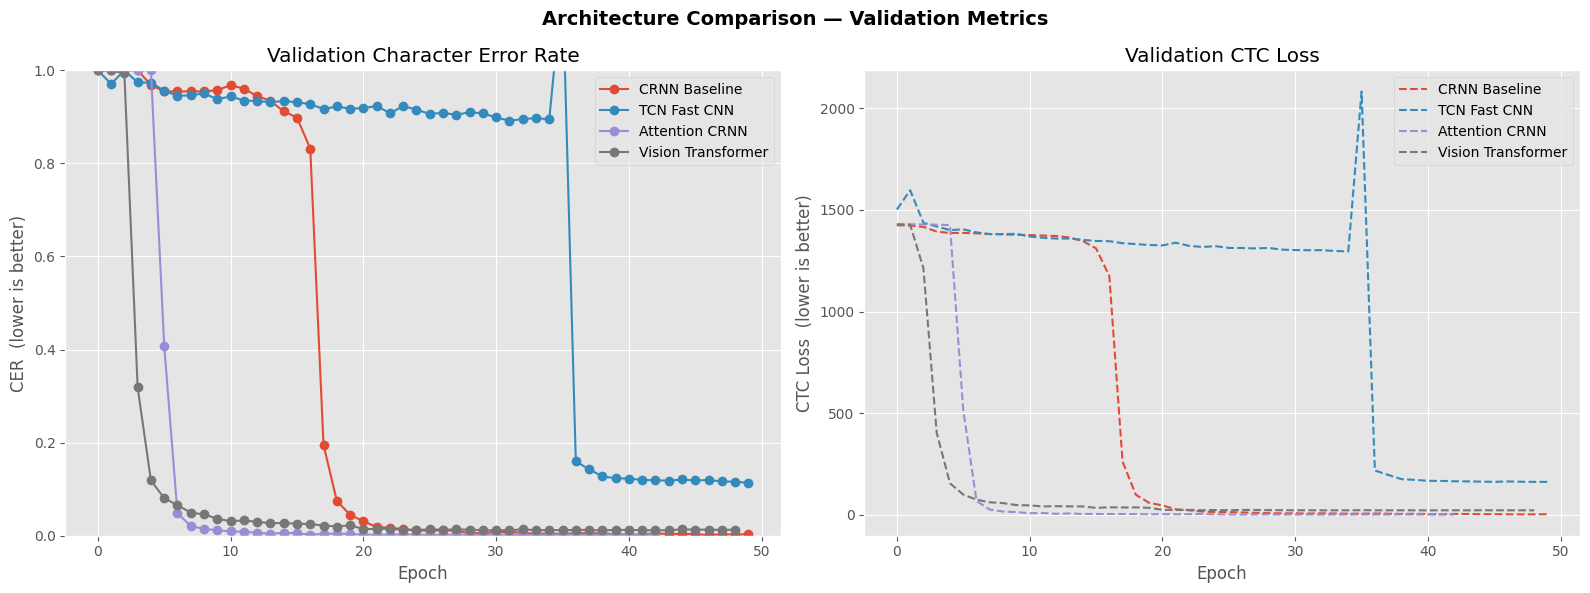

In [ ]:
plt.style.use("ggplot")
fig, axes = plt.subplots(1, 2, figsize = (16, 6))
fig.suptitle("Architecture Comparison Validation Metrics", fontsize = 14, fontweight = "bold")

for name, hist in training_histories.items():
    if "val_cer" in hist.history:
        axes[0].plot(hist.history["val_cer"], marker = "o", label = name)

axes[0].set_title("Validation Character Error Rate")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CER lower is better")
axes[0].set_ylim(0, 1.0)
axes[0].legend()

for name, hist in training_histories.items():
    if "val_loss" in hist.history:
        axes[1].plot(hist.history["val_loss"], linestyle = "--", label = name)

axes[1].set_title("Validation CTC Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CTC Loss lower is better")
axes[1].legend()

plt.tight_layout()
plt.show()

# Prediction Using the Best Model Obtained

In [ ]:
def process_test_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels = 1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.transpose(img, perm = [1, 0, 2])
    return img

In [ ]:
test_image_paths = sorted([str(p) for p in TEST_IMAGES_DIR.glob("*.png")])
test_dataset = tf.data.Dataset.from_tensor_slices(test_image_paths)
test_dataset = test_dataset.map(process_test_image, num_parallel_calls = tf.data.AUTOTUNE).batch(BATCH_SIZE)

In [5]:
best_model_name = ""
lowest_cer = float("inf")

for name, hist in training_histories.items():
    min_cer = min(hist.history["val_cer"])
    if min_cer < lowest_cer:
        lowest_cer = min_cer
        best_model_name = name

print(f"The winning architecture is {best_model_name} with a CER of {lowest_cer:.4f}")

best_model = models_to_test[best_model_name]

final_prediction_model = keras.models.Model(
    inputs = best_model.inputs[0],
    outputs = best_model.get_layer(name="dense_out").output
)

print("Running test images through the winning model, please wait...")
preds = final_prediction_model.predict(test_dataset)

input_len = np.ones(preds.shape[0]) * preds.shape[1]
decoded_preds, _ = keras.backend.ctc_decode(preds, input_length = input_len, greedy. =True)
decoded_preds = decoded_preds[0]

results = []

for i in range(len(test_image_paths)):
    pred_indices = decoded_preds[i][decoded_preds[i] != -1]
    pred_text = tf.strings.reduce_join(num_to_char(pred_indices)).numpy().decode("utf-8")
    filename = Path(test_image_paths[i]).name
    results.append({"image": filename, "prediction": pred_text})

submission_df = pd.DataFrame(results)
submission_df["img_number"] = submission_df["image"].str.extract(r"(\d+)").astype(int)
submission_df = submission_df.sort_values("img_number")
submission_df = submission_df.drop(columns=["img_number"])

final_csv_path = "/content/drive/MyDrive/submission_Ritesh_Choudhary_24113105.csv"
submission_df.to_csv(final_csv_path, index=False)

print(f"Submission saved successfully to {final_csv_path}")

The winning architecture is CRNN Baseline with a CER of 0.0016
Running test images through the winning model, please wait...
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step
Submission saved successfully to /content/drive/MyDrive/submission_Ritesh_Choudhary_24113105.csv


# Saving the Prediction Model for Future Use

In [ ]:
save_dir = "/content/drive/MyDrive/OCR_Models_Backup"
os.makedirs(save_dir, exist_ok = True)

print("Saving all prediction models to Google Drive...")

for model_name, full_model in models_to_test.items():
    safe_name = model_name.replace(" ", "_")
    pred_model = keras.models.Model(
        inputs = full_model.inputs[0],
        outputs = full_model.get_layer(name="dense_out").output
    )
    save_path = os.path.join(save_dir, f"{safe_name}_prediction.keras")
    pred_model.save(save_path)
    print(f"Saved: {save_path}")

print("\nAll prediction models successfully backed up to Drive!")

Saving all prediction models to Google Drive...
Saved: /content/drive/MyDrive/OCR_Models_Backup/CRNN_Baseline_prediction.keras
Saved: /content/drive/MyDrive/OCR_Models_Backup/TCN_Fast_CNN_prediction.keras
Saved: /content/drive/MyDrive/OCR_Models_Backup/Attention_CRNN_prediction.keras
Saved: /content/drive/MyDrive/OCR_Models_Backup/Vision_Transformer_prediction.keras

All prediction models successfully backed up to Drive!
